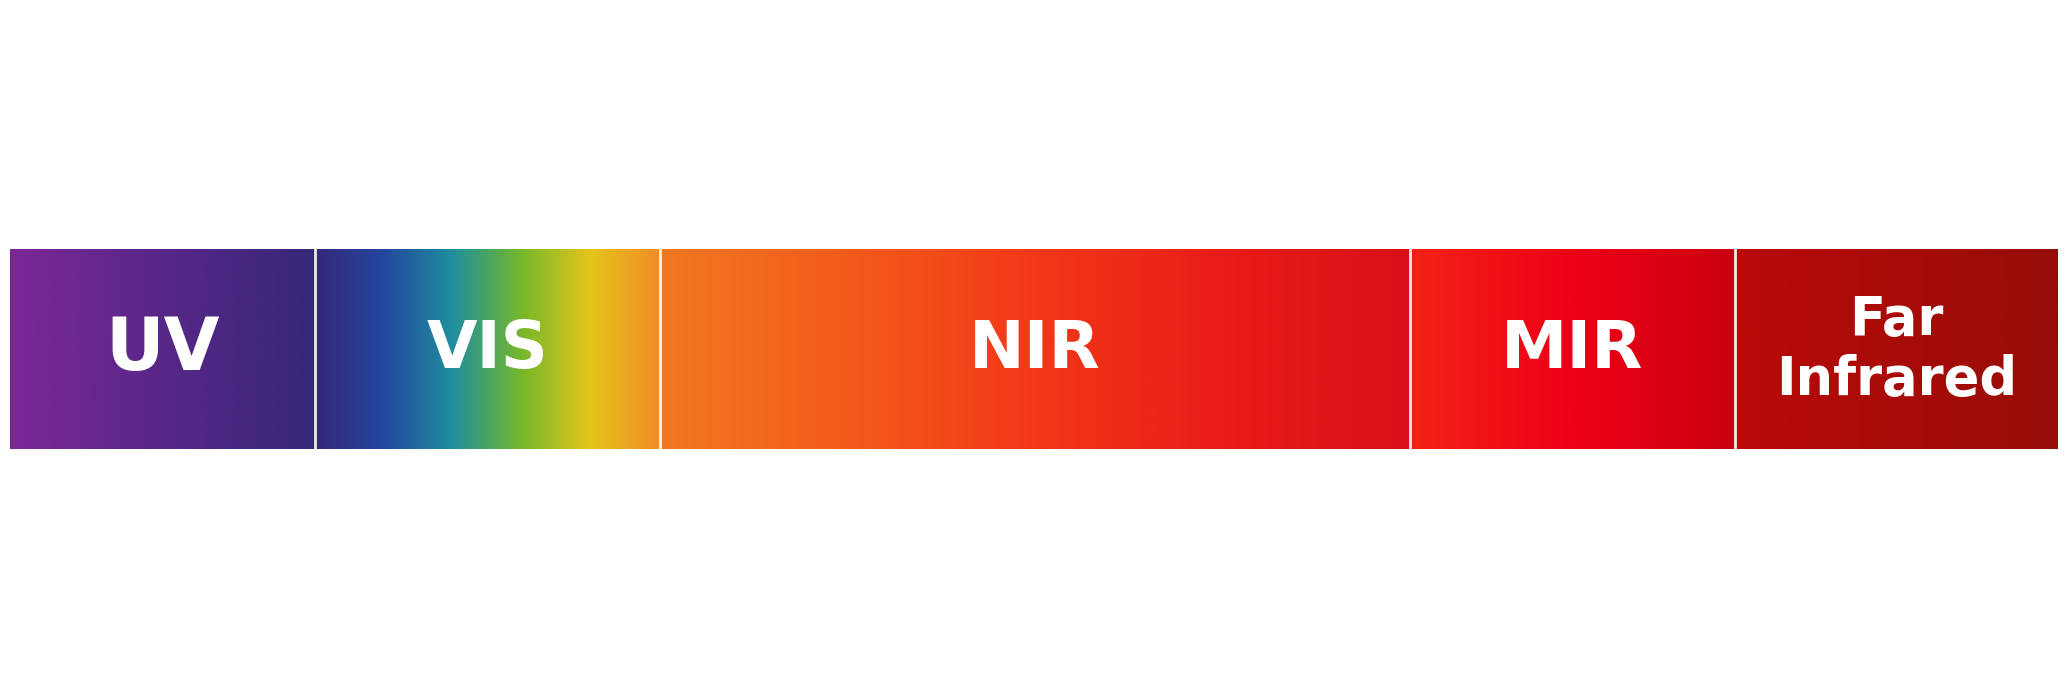

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20.48, 6.8), dpi=100)

ax.set_xlim(0, 2048)
ax.set_ylim(0, 680)
ax.axis("off")

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ------------------------------------------------------------
# Position of the coloured spectral bar
# ------------------------------------------------------------
y_bottom = 240
y_top = 440

# Approximate boundaries matching the image
boundaries = [
    0,
    305,    # UV / VIS
    650,    # VIS / NIR      <- VIS narrower
    1400,   # NIR / MIR
    1725,   # MIR / Far IR   <- MIR narrower
    2048
]

# ------------------------------------------------------------
# Colour gradients for each section
# ------------------------------------------------------------
sections = [
    # UV
    {
        "x0": boundaries[0],
        "x1": boundaries[1],
        "colors": ["#7b2797", "#352779"],
        "label": "UV",
        "fontsize": 52
    },

    # VIS
    {
        "x0": boundaries[1],
        "x1": boundaries[2],
        "colors": [
            "#352779",  # purple-blue, continuing from UV
            "#2448a0",  # blue
            "#1f8f9d",  # cyan/greenish
            "#76b82a",  # green
            "#e5c51a",  # yellow
            "#f28c28"   # orange
        ],
        "label": "VIS",
        "fontsize": 47
    },

    # NIR
    {
        "x0": boundaries[2],
        "x1": boundaries[3],
        "colors": [
            "#f07822",  # orange, continuing from VIS
            "#f45b1a",  # orange-red
            "#f23818",  # red-orange
            "#e91c18",  # red
            "#d91018"   # deeper red
        ],
        "label": "NIR",
        "fontsize": 48
    },

    # MIR
    {
        "x0": boundaries[3],
        "x1": boundaries[4],
        "colors": ["#f32216", "#ee0016", "#cb0011"],
        "label": "MIR",
        "fontsize": 48
    },

    # Far infrared
    {
        "x0": boundaries[4],
        "x1": boundaries[5],
        "colors": ["#ba0a08", "#960d08"],
        "label": "Far\nInfrared",
        "fontsize": 38
    }
]

# ------------------------------------------------------------
# Function to draw a smooth horizontal gradient
# ------------------------------------------------------------
def draw_gradient(ax, x0, x1, y0, y1, colors, resolution=1000):

    gradient = np.linspace(0, 1, resolution)[None, :]

    cmap = LinearSegmentedColormap.from_list(
        "custom_gradient",
        colors
    )

    ax.imshow(
        gradient,
        extent=[x0, x1, y0, y1],
        origin="lower",
        aspect="auto",
        cmap=cmap,
        interpolation="bicubic"
    )


# ------------------------------------------------------------
# Draw sections and labels
# ------------------------------------------------------------
for section in sections:

    x0 = section["x0"]
    x1 = section["x1"]

    draw_gradient(
        ax,
        x0,
        x1,
        y_bottom,
        y_top,
        section["colors"]
    )

    ax.text(
        (x0 + x1) / 2,
        (y_bottom + y_top) / 2,
        section["label"],
        color="white",
        fontsize=section["fontsize"],
        fontweight="bold",
        ha="center",
        va="center",
        family="sans-serif"
    )


# ------------------------------------------------------------
# Thin white vertical separators
# ------------------------------------------------------------
for x in boundaries[1:-1]:
    ax.plot(
        [x, x],
        [y_bottom, y_top],
        color="white",
        linewidth=2,
        alpha=0.9
    )


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
plt.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1
)

plt.savefig(
    "wavelength_regions.png",
    dpi=100,
    bbox_inches="tight",
    pad_inches=0,
    facecolor="white"
)

plt.show()